# This implements SEACells directly onto sc_data.h5ad, just to get an idea of the metacells

In [19]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells 
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad

In [20]:
import warnings
warnings.simplefilter("ignore")

In [21]:
%matplotlib inline
sns.set_style("ticks")
matplotlib.rcParams['figure.figsize']= [4,4]
matplotlib.rcParams['figure.dpi']= 100

In [22]:
ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/MERFISH_Data/sc_data_1.h5ad")


In [23]:
ad

AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'hvg'
    layers: 'log'

In [24]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

In [25]:
ad.uns["celltype_colors"] = cell_type_palette
ad.uns["cell_label_colors"] = cell_label_palette  

In [26]:
ad.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'hvg', 'celltype_colors', 'cell_label_colors'
    layers: 'log'>

## Plotting cell types for refernce

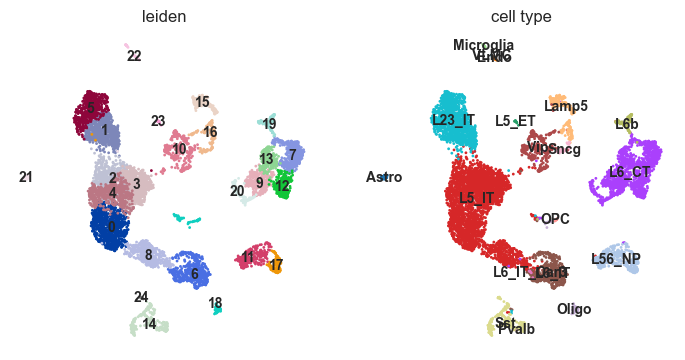

In [27]:
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
sc.pp.highly_variable_genes(ad, n_top_genes=1500)
ad = ad[:, ad.var.highly_variable]
sc.tl.pca(ad, svd_solver='arpack')
sc.pp.neighbors(ad, n_neighbors=10, n_pcs=40)
sc.tl.leiden(ad)

sc.tl.umap(ad)
sc.pl.scatter(ad, basis='umap', color=['leiden', 'cell_type'], frameon=False, legend_loc='on data')

## Preprocess

In [28]:
raw_ad=sc.AnnData(ad.X)

In [29]:
raw_ad.obs_names, raw_ad.var_names=ad.obs_names, ad.var_names
ad.raw=raw_ad

In [30]:
raw_ad

AnnData object with n_obs × n_vars = 7416 × 1500

In [31]:
ad

AnnData object with n_obs × n_vars = 7416 × 1500
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', 'cell_label', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep_genes'
    uns: 'hvg', 'celltype_colors', 'cell_label_colors', 'log1p', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'log'
    obsp: 'distances', 'connectivities'

In [32]:
sc.pp.pca(ad, n_comps=50, use_highly_variable=True)

## Running SeaCells

In [33]:
#Construct kernel matrix

n_SEACells=99
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [34]:
model= SEACells.core.SEACells(ad, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              n_waypoint_eigs=n_waypoint_eigs,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [35]:
model.construct_kernel_matrix()
M=model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/7416 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/7416 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/7416 [00:00<?, ?it/s]

Constructing CSR matrix...


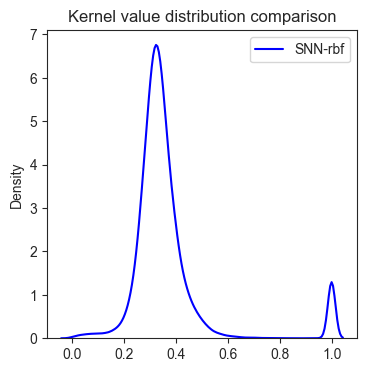

In [36]:
sns.kdeplot(M.data, label="SNN-rbf", color="blue")
plt.legend()
plt.title("Kernel value distribution comparison")
plt.show()

In [37]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 90 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 19/19 [00:00<00:00, 298.88it/s]

Selecting 9 cells from greedy initialization.


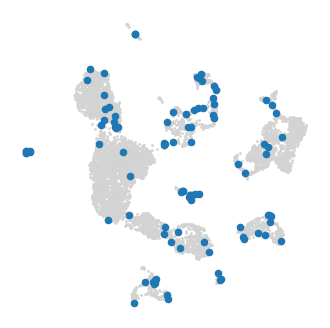

In [38]:
SEACells.plot.plot_initialization(ad, model)

In [39]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
  DEBUG: _updateA norms: kernel_matrix=1.57e+02, P=9.10e+01, PtP=4.22e+01, PtM=9.10e+01
 _updateA iter 1: Grad norm: 2.22e+02
 _updateA iter 2: Grad norm: 7.07e+02
 _updateA iter 3: Grad norm: 7.21e+02
 _updateA iter 4: Grad norm: 5.21e+02
 _updateA iter 5: Grad norm: 4.40e+02
 _updateA iter 6: Grad norm: 3.64e+02
 _updateA iter 7: Grad norm: 3.10e+02
 _updateA iter 8: Grad norm: 2.73e+02
 _updateA iter 9: Grad norm: 2.42e+02
 _updateA iter 10: Grad norm: 2.19e+02
 _updateA iter 11: Grad norm: 2.06e+02
 _updateA iter 12: Grad norm: 1.97e+02
 _updateA iter 13: Grad norm: 1.85e+02
 _updateA iter 14: Grad norm: 1.76e+02
 _updateA iter 15: Grad norm: 1.71e+02
 _updateA iter 16: Grad norm: 1.68e+02
 _updateA iter 17: Grad norm: 1.65e+02
 _updateA iter 18: Grad norm: 1.59e+02
 _updateA iter 19: Grad norm: 1.53e+02
 _updateA iter 20: Grad norm: 1.47e+02
 _updateA iter 21: Grad norm: 1.44e+02
 _updateA iter 22: Grad norm: 1.41e+02
 _updateA iter 23: Grad norm: 1.

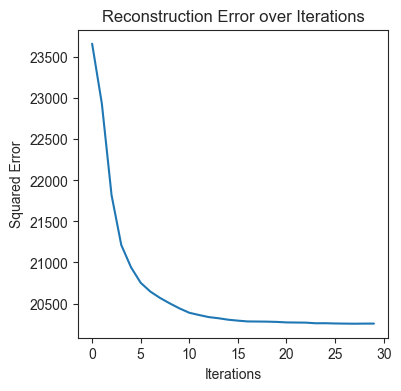

In [45]:
model.plot_convergence()

In [41]:
help(SEACells.plot.plot_2D)


Help on function plot_2D in module SEACells.plot:

plot_2D(ad, key='X_umap', colour_metacells=True, title='Metacell Assignments', save_as=None, show=True, cmap='Set2', figsize=(5, 5), SEACell_size=20, cell_size=10)
    Plot 2D visualization of metacells using the embedding provided in 'key'.
    
    :param ad: annData containing 'Metacells' label in .obs
    :param key: (str) 2D embedding of data. Default: 'X_umap'
    :param colour_metacells: (bool) whether to colour cells by metacell assignment. Default: True
    :param title: (str) title for figure
    :param save_as: (str or None) file name to which figure is saved
    :param cmap: (str) matplotlib colormap for metacells. Default: 'Set2'
    :param figsize: (int,int) tuple of integers representing figure size



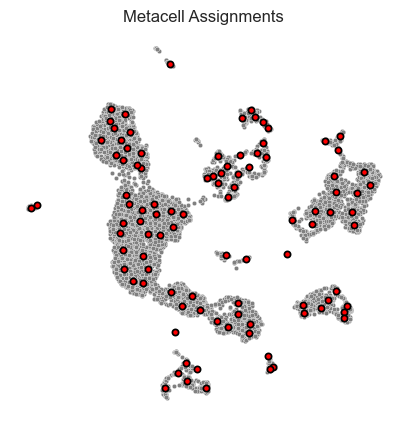

In [46]:
SEACells.plot.plot_2D(ad, colour_metacells=False)

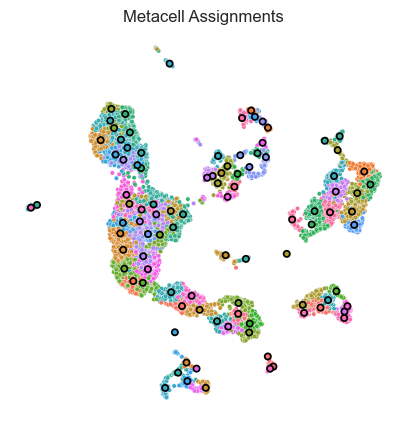

In [43]:
SEACells.plot.plot_2D(ad, colour_metacells=True)

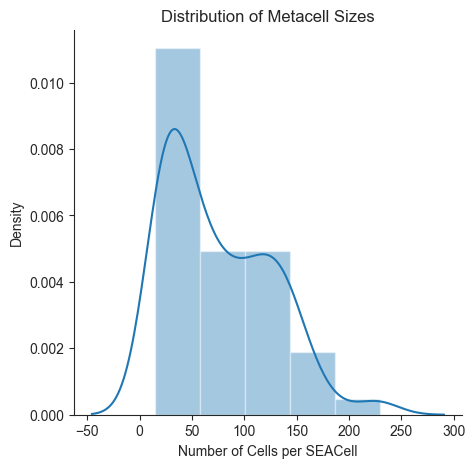

,size
SEACell,
SEACell-0,64
SEACell-1,17
SEACell-10,15
SEACell-11,43
SEACell-12,97
...,...
SEACell-94,49
SEACell-95,55
SEACell-96,149


In [44]:
SEACells.plot.plot_SEACell_sizes(ad, bins=5)